# Diabetes Regression (Deep Learning)
`BMI` 수치(연속값)를 예측하는 딥러닝 모델

※ Regression은 y가 연속적인 숫자 → 원핫인코딩 없음, 출력 뉴런 1개, loss=mse

In [1]:
import pandas as pd
import numpy as np

path = '../../data/diabetes.csv'

df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # 불필요한 Unnamed 컬럼 제거

# Regression: BMI를 예측 대상(y)으로 사용
X = df.drop(['BMI', 'Outcome'], axis=1) # 분류형 라벨도 제외
y = df['BMI']

print(y.describe())

count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64


Epoch 1/50


c:\Users\kiw60\Desktop\intro-to-ai\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1059.2094 - mae: 31.6238 - val_loss: 987.4595 - val_mae: 30.3960
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 926.9947 - mae: 29.5432 - val_loss: 819.6878 - val_mae: 27.6301
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 717.5880 - mae: 25.8430 - val_loss: 561.4495 - val_mae: 22.6432
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 438.0798 - mae: 19.5762 - val_loss: 281.8790 - val_mae: 15.3056
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 213.4785 - mae: 12.5753 - val_loss: 122.9075 - val_mae: 9.0189
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 119.3889 - mae: 8.6171 - val_loss: 92.9666 - val_mae: 7.3891
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 96.6028 - mae: 7.4948 - val_loss: 86.5350 - val_mae: 6.9959
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 96.0741 - mae: 7.5183 - val_loss: 82.4140 - val_mae: 6.8901
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

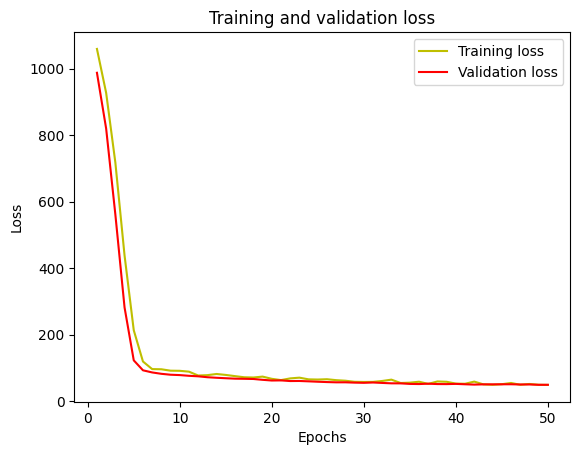

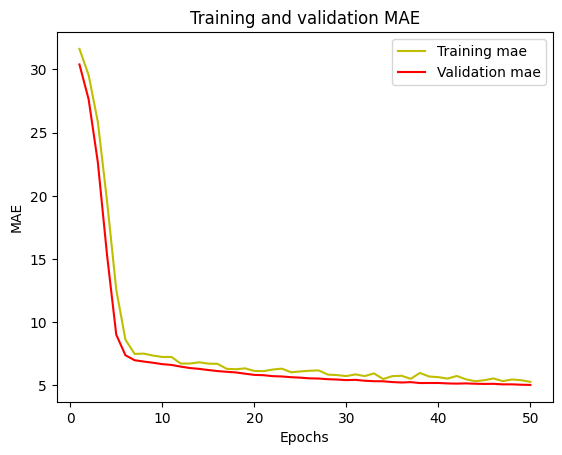

MSE  : 50.5715
MAE  : 5.0163
R²   : 0.1480


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

scaler = StandardScaler()
X = scaler.fit_transform(X)   # numpy 배열로 변환됨

# 회귀(Regression)에서는 타겟이 연속값이므로 원-핫 인코딩을 하지 않습니다.
# Y = pd.get_dummies(y).values 삭제됨

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)   # Regression: 뉴런 1개, 활성화 함수 없음(linear)
])

model.compile(
    optimizer="adam",
    loss="mse",        # Regression 손실함수: Mean Squared Error
    metrics=["mae"]    # 평가지표: Mean Absolute Error
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test).flatten()

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

plt.plot(epochs_range, loss, 'y', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

mae = history.history['mae']
val_mae = history.history['val_mae']
plt.plot(epochs_range, mae, 'y', label='Training mae')
plt.plot(epochs_range, val_mae, 'r', label='Validation mae')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

# Accuracy of the predicted values
print(f'MSE  : {mean_squared_error(y_test, y_pred):.4f}')
print(f'MAE  : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R²   : {r2_score(y_test, y_pred):.4f}')